robot pos (center) on image is
-1.24, -0.14, -0.002261
quat = 0.999991, 3.16436e-09, 0.00415322, -2.26455e-07

transfo from robot_pos to tag aruco center is z+0.43

cam estimated pos from table is
Position Estimée : [-0.22523543  1.11958516  0.9904527 ]



In [36]:
# Force external files to be reloaded
import importlib
# importlib.reload()

# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get

# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import transforms3d.quaternions as tf_quat
import transforms3d.affines as tf_aff
import tf_transformations as tf_trans

In [37]:
# USE_EXTRINSIC_CALIBRATION = False
IMAGE_USED = 2 # 1 or 2

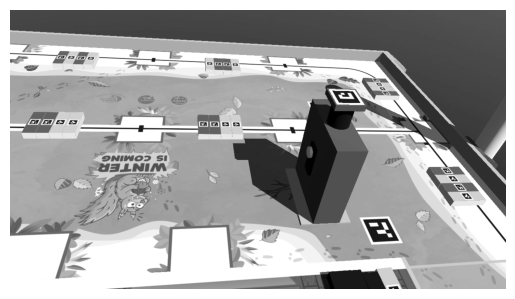

In [38]:
# Load an image using OpenCV
img_camera = cv2.imread('../../ressources/watchtower_view_with_robot'+str(IMAGE_USED)+'.png', 0) # Grayscale

# Display the image using matplotlib
plt.imshow(img_camera, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [39]:
# Matrice Intrinsèque
camera_matrix = np.array([
    [914.0151876932167, 0.0, 640.0],
    [0.0, 914.0151876932167, 360.0],
    [0.0, 0.0, 1.0]
])
dist_coeffs = np.zeros(5)

In [40]:
USE_EXTRINSIC_CALIBRATION = False

if USE_EXTRINSIC_CALIBRATION:
    # values obtained from extrinsic calibration from other notebook
    t_table_cam = np.array([-0.22523543,  1.11958516,  0.9904527])
    # R_table_cam = np.array([[-9.83260412e-01,  1.39232248e-01,  1.17530177e-01],
    #                         [-7.54271853e-05,  6.44729645e-01, -7.64410675e-01],
    #                         [-1.82205806e-01, -7.51623620e-01, -6.33926634e-01]])


    R_table_cam = [[-1.82205806e-01, -7.54271853e-05, -9.83260412e-01],
                   [-7.51623620e-01, 6.44729645e-01, 1.39232248e-01],
                   [-6.33926634e-01, -7.64410675e-01, 1.17530177e-01]]
    
    T_table_cam = np.eye(4)
    T_table_cam[:3, :3] = R_table_cam
    T_table_cam[:3, 3] = t_table_cam.flatten()

else:
# T_table_cam:
#  [[-1.82165757e-01 -7.52044917e-01 -6.33438300e-01  1.42840693e+00]
#  [ 9.83267836e-01 -1.39329870e-01 -1.17352249e-01  4.93463443e-01]
#  [-2.71402062e-06 -6.44217068e-01  7.64842709e-01 -3.56717763e-02]
#  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
    # values obtained from simulation true camera pose
    camera_support_in_world_pos = np.array([-0.225, 1.12, 0.08])
    camera_support_in_world_quat_xyzw = np.array([0, 0, -0.707108, 0.707105])
    camera_in_support_pos = np.array([0.0, 0.0, 0.91])
    camera_in_support_quat_xyzw = np.array([-0.031363, 0.34146, -0.0859194, 0.935435])

    T_world_support = tf_trans.concatenate_matrices(
        tf_trans.translation_matrix(camera_support_in_world_pos),
        tf_trans.quaternion_matrix(camera_support_in_world_quat_xyzw)
    )
    T_support_camera = tf_trans.concatenate_matrices(
        tf_trans.translation_matrix(camera_in_support_pos),
        tf_trans.quaternion_matrix(camera_in_support_quat_xyzw)
    )
    T_table_cam = T_world_support @ T_support_camera
    T_table_cam = np.linalg.inv(T_table_cam)
    R_table_cam = T_table_cam[:3, :3]
    t_table_cam = T_table_cam[:3, 3].reshape(3, 1)

    # On WEBOTS, the camera looks along +X. But in OpenCV, the camera looks along +Z.
    # TODO

print("T_table_cam:\n", T_table_cam)


T_table_cam:
 [[-1.82165757e-01 -7.52044917e-01 -6.33438300e-01  1.42840693e+00]
 [ 9.83267836e-01 -1.39329870e-01 -1.17352249e-01  4.93463443e-01]
 [-2.71402062e-06 -6.44217068e-01  7.64842709e-01 -3.56717763e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [41]:
# Ground truth robot position (center at ground level)
if IMAGE_USED == 1:
    robot_pos_true = np.array([-1.24, -0.14, -0.002261])
elif IMAGE_USED == 2:
    robot_pos_true = np.array([-0.700161, 0.219973, -0.00257451])


=== ROBOT ID 1 ===
Position: X=-0.4350, Y=0.2348, Z=1.2431
Error: 127.37 cm
Reprojection error: 0.1154 px
Yaw: 78.77°


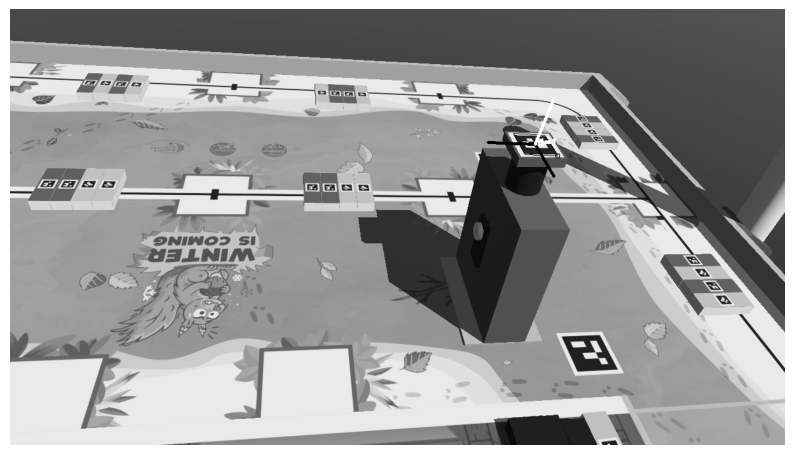

In [42]:
ARUCO_SIZE = 0.07
ROBOT_HEIGHT = 0.43

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

corners, ids, _ = detector.detectMarkers(img_camera)
img_debug = img_camera.copy()

if ids is not None:
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.0001)
    
    for i in range(len(corners)):
        cv2.cornerSubPix(img_camera, corners[i], (5, 5), (-1, -1), criteria)

    for i in range(len(ids)):
        tag_id = ids[i][0]
        
        if 1 <= tag_id <= 10:
            obj_pts = np.array([
                [-ARUCO_SIZE/2,  ARUCO_SIZE/2, 0],
                [ ARUCO_SIZE/2,  ARUCO_SIZE/2, 0],
                [ ARUCO_SIZE/2, -ARUCO_SIZE/2, 0],
                [-ARUCO_SIZE/2, -ARUCO_SIZE/2, 0]
            ], dtype=np.float32)

            _, rvec_tag, tvec_tag = cv2.solvePnP(obj_pts, corners[i], camera_matrix, dist_coeffs, 
                                                flags=cv2.SOLVEPNP_IPPE_SQUARE)

            R_tag, _ = cv2.Rodrigues(rvec_tag)
            T_cam_tag = np.eye(4)
            T_cam_tag[:3, :3] = R_tag
            T_cam_tag[:3, 3] = tvec_tag.flatten()
            
            T_table_tag = np.linalg.inv(T_table_cam) @ T_cam_tag
            pos_tag_table = T_table_tag[:3, 3]

            pos_robot_est = np.array([
                pos_tag_table[0], 
                pos_tag_table[1], 
                pos_tag_table[2] - ROBOT_HEIGHT
            ])

            yaw_robot = np.arctan2(T_table_tag[1, 0], T_table_tag[0, 0])
            error_xyz = np.linalg.norm(pos_robot_est - robot_pos_true)
            
            points_reprojets, _ = cv2.projectPoints(obj_pts, rvec_tag, tvec_tag, camera_matrix, dist_coeffs)
            points_reprojets = points_reprojets.reshape(-1, 2)
            reproj_error = np.mean(np.linalg.norm(corners[i].reshape(-1, 2) - points_reprojets, axis=1))

            print(f"=== ROBOT ID {tag_id} ===")
            print(f"Position: X={pos_robot_est[0]:.4f}, Y={pos_robot_est[1]:.4f}, Z={pos_robot_est[2]:.4f}")
            print(f"Error: {error_xyz*100:.2f} cm")
            print(f"Reprojection error: {reproj_error:.4f} px")
            print(f"Yaw: {np.degrees(yaw_robot):.2f}°")

            cv2.aruco.drawDetectedMarkers(img_debug, [corners[i]], np.array([[tag_id]]))
            cv2.drawFrameAxes(img_debug, camera_matrix, dist_coeffs, rvec_tag, tvec_tag, 0.1)
            break
else:
    print("No ArUco markers detected")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


=== ROBOT ID 1 (Z FIXÉ À 0.43m) ===
POSITION : X=-0.0532, Y=1.8458, Z=0.0000
ERREUR   : 174.98 cm
REPROJ   : 0.1154 px | ANGLE : 78.77°


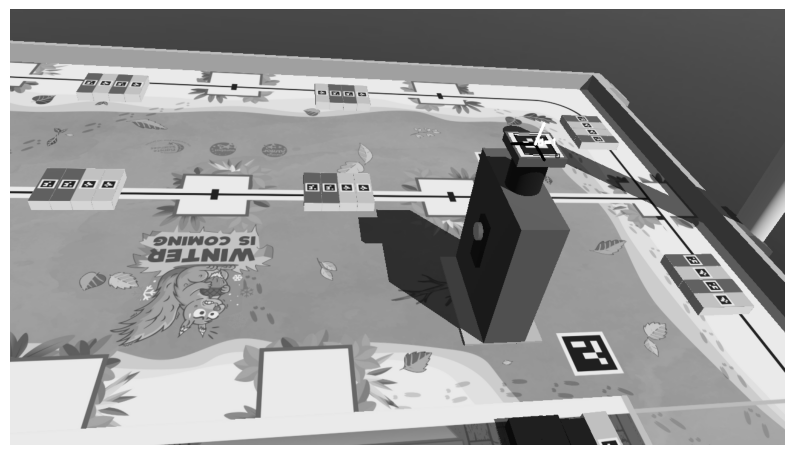

In [43]:
# --- CELLULE : LOCALISATION PRÉCISE (Z FIXÉ) - CORRIGÉE ---

ARUCO_SIZE = 0.07   
ROBOT_HEIGHT = 0.43 

# 1. INITIALISATION
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

corners, ids, _ = detector.detectMarkers(img_camera)
img_debug = img_camera.copy()

if ids is not None:
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.0001)
    
    for i in range(len(corners)):
        cv2.cornerSubPix(img_camera, corners[i], (5, 5), (-1, -1), criteria)

    for i in range(len(ids)):
        tag_id = ids[i][0]
        if 1 <= tag_id <= 10:
            # --- CALCUL DE LA POSE INITIALE ---
            obj_pts = np.array([[-ARUCO_SIZE/2, ARUCO_SIZE/2, 0], [ARUCO_SIZE/2, ARUCO_SIZE/2, 0], 
                                [ARUCO_SIZE/2, -ARUCO_SIZE/2, 0], [-ARUCO_SIZE/2, -ARUCO_SIZE/2, 0]], dtype=np.float32)
            
            _, rvec_tag, tvec_tag = cv2.solvePnP(obj_pts, corners[i], camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_IPPE_SQUARE)

            # --- MÉTHODE DU RAY-CASTING POUR FIXER Z ---
            center_px = np.mean(corners[i][0], axis=0)
            pixel_homo = np.array([center_px[0], center_px[1], 1.0])
            ray_cam = np.linalg.inv(camera_matrix) @ pixel_homo
            
            # Repère Table
            R_world_cam = R_table_cam.T
            t_world_cam = -R_table_cam.T @ t_table_cam.reshape(3,1) # Force shape (3,1)
            ray_world = R_world_cam @ ray_cam.reshape(3,1)
            
            # Intersection Rayon / Plan Z = 0.43
            cam_z = t_world_cam[2, 0]
            lmbda = (ROBOT_HEIGHT - cam_z) / ray_world[2, 0]
            
            pos_tag_fixed = t_world_cam + lmbda * ray_world
            pos_tag_fixed = pos_tag_fixed.flatten() # On transforme en vecteur plat (3,)

            # --- RÉSULTATS FINAUX ---
            # Le robot est au sol (Z=0), le tag est à Z=ROBOT_HEIGHT
            pos_robot_est = np.array([pos_tag_fixed[0], pos_tag_fixed[1], pos_tag_fixed[2] - ROBOT_HEIGHT])
            
            # Orientation (Yaw) via solvePnP
            R_tag, _ = cv2.Rodrigues(rvec_tag)
            T_cam_tag = np.eye(4); T_cam_tag[:3, :3] = R_tag; T_cam_tag[:3, 3] = tvec_tag.flatten()
            T_table_cam = np.eye(4); T_table_cam[:3, :3] = R_table_cam; T_table_cam[:3, 3] = t_table_cam.flatten()
            T_table_tag = np.linalg.inv(T_table_cam) @ T_cam_tag
            yaw_robot = np.arctan2(T_table_tag[1, 0], T_table_tag[0, 0])

            # Reprojection
            pts_reproj, _ = cv2.projectPoints(obj_pts, rvec_tag, tvec_tag, camera_matrix, dist_coeffs)
            reproj_err = np.mean(np.linalg.norm(corners[i].reshape(-1, 2) - pts_reproj.reshape(-1, 2), axis=1))

            # --- AFFICHAGE ---
            print(f"=== ROBOT ID {tag_id} (Z FIXÉ À {ROBOT_HEIGHT}m) ===")
            # L'accès par [0], [1], [2] fonctionne maintenant car pos_robot_est est "flat"
            print(f"POSITION : X={pos_robot_est[0]:.4f}, Y={pos_robot_est[1]:.4f}, Z={pos_robot_est[2]:.4f}")
            print(f"ERREUR   : {np.linalg.norm(pos_robot_est - robot_pos_true.flatten())*100:.2f} cm")
            print(f"REPROJ   : {reproj_err:.4f} px | ANGLE : {np.degrees(yaw_robot):.2f}°")

            cv2.aruco.drawDetectedMarkers(img_debug, [corners[i]], np.array([[tag_id]]))
            cv2.drawFrameAxes(img_debug, camera_matrix, dist_coeffs, rvec_tag, tvec_tag, 0.05)
            break
else:
    print("ERREUR : Aucun tag détecté.")

plt.figure(figsize=(10, 6)); plt.imshow(cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()